In [2]:
# ============================================================
# CELL 1 — Imports and CPU Setup
# Forces CPU usage (prevents GPU instability issues)
# ============================================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization, Concatenate
)

In [3]:
# ============================================================
# CELL 2 — Dynamic Project Root Detection
# Ensures correct paths regardless of working directory
# ============================================================

# Detect project root dynamically
if os.path.basename(os.getcwd()) == "training":
    PROJECT_ROOT = os.path.dirname(os.getcwd())
else:
    PROJECT_ROOT = os.getcwd()

DATASET_PATH = os.path.join(PROJECT_ROOT, "data", "DEAM", "DEAM_audio", "MEMD_audio")

ANNOTATION_PATH_1 = os.path.join(
    PROJECT_ROOT,
    "data", "DEAM", "DEAM_Annotations", "annotations",
    "annotations averaged per song", "song_level",
    "static_annotations_averaged_songs_1_2000.csv"
)

ANNOTATION_PATH_2 = os.path.join(
    PROJECT_ROOT,
    "data", "DEAM", "DEAM_Annotations", "annotations",
    "annotations averaged per song", "song_level",
    "static_annotations_averaged_songs_2000_2058.csv"
)

print("Project Root:", PROJECT_ROOT)
print("Dataset Exists:", os.path.exists(DATASET_PATH))
print("Audio Files:", len(os.listdir(DATASET_PATH)))

Current working directory: C:\Users\adith\Documents\Study\Coding\Muud\training
Project root: C:\Users\adith\Documents\Study\Coding\Muud
Dataset folder exists: True
Number of audio files: 1802
Annotation 1 exists: True
Annotation 2 exists: True


In [4]:
# ============================================================
# CELL 3 — Load and Clean Annotation Files
# Keeps only song_id, valence_mean, arousal_mean
# ============================================================

ann1 = pd.read_csv(ANNOTATION_PATH_1)
ann2 = pd.read_csv(ANNOTATION_PATH_2)

annotations = pd.concat([ann1, ann2], ignore_index=True)

# Remove leading/trailing spaces in column names
annotations.columns = annotations.columns.str.strip()

annotations = annotations[["song_id", "valence_mean", "arousal_mean"]]

# Ensure song_id is integer
annotations["song_id"] = annotations["song_id"].astype(int)

print("Total annotated songs:", len(annotations))
annotations.head()

Total annotated songs: 1802


,song_id,valence_mean,arousal_mean
0,2,3.1,3.0
1,3,3.5,3.3
2,4,5.7,5.5
3,5,4.4,5.3
4,7,5.8,6.4


In [5]:
# ============================================================
# CELL 4 — Audio Processing Constants
# ============================================================

SAMPLE_RATE = 22050
SEGMENT_DURATION = 3
SAMPLES_PER_SEGMENT = SAMPLE_RATE * SEGMENT_DURATION
N_MELS = 128
MAX_SEGMENTS = 10

print("Samples per segment:", SAMPLES_PER_SEGMENT)

Samples per segment: 66150


In [6]:
# ============================================================
# CELL 5 — Extract Mel Spectrogram + Handcrafted Features
# Returns:
#   - Mel spectrogram segments
#   - Handcrafted features (tempo, centroid, rms, zcr)
#   - Valence & arousal labels
# ============================================================

def extract_features_with_stats(file_path, valence, arousal):
    segments = []
    handcrafted = []
    labels = []

    try:
        signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

        total_samples = len(signal)
        num_segments = total_samples // SAMPLES_PER_SEGMENT

        for s in range(min(num_segments, MAX_SEGMENTS)):
            start = s * SAMPLES_PER_SEGMENT
            end = start + SAMPLES_PER_SEGMENT
            segment = signal[start:end]

            # -------- Mel Spectrogram --------
            mel = librosa.feature.melspectrogram(
                y=segment,
                sr=sr,
                n_mels=N_MELS
            )

            mel = librosa.power_to_db(mel)

            if np.std(mel) != 0:
                mel = (mel - np.mean(mel)) / np.std(mel)

            # -------- Handcrafted Features --------
            tempo, _ = librosa.beat.beat_track(y=segment, sr=sr)
            centroid = np.mean(librosa.feature.spectral_centroid(y=segment, sr=sr))
            rms = np.mean(librosa.feature.rms(y=segment))
            zcr = np.mean(librosa.feature.zero_crossing_rate(segment))

            segments.append(mel)
            handcrafted.append([tempo, centroid, rms, zcr])
            labels.append([valence, arousal])

        return segments, handcrafted, labels

    except Exception as e:
        print("Error processing:", file_path)
        print(e)
        return [], [], []

In [ ]:
# ============================================================
# CELL 6 — Build Full Dataset
# ============================================================

X_mel = []
X_stats = []
y = []

for _, row in annotations.iterrows():
    song_id = int(row["song_id"])  # Force int — iterrows() silently converts to float!
    valence = row["valence_mean"]
    arousal = row["arousal_mean"]

    file_path = os.path.join(DATASET_PATH, f"{song_id}.mp3")

    if os.path.exists(file_path):
        mel, stats, labels = extract_features_with_stats(
            file_path, valence, arousal
        )

        X_mel.extend(mel)
        X_stats.extend(stats)
        y.extend(labels)

print("Total segments created:", len(X_mel))

Working dir inside dataset loop: C:\Users\adith\Documents\Study\Coding\Muud\training
Dataset path used: C:\Users\adith\Documents\Study\Coding\Muud\data\DEAM\DEAM_audio\MEMD_audio
Absolute dataset path: C:\Users\adith\Documents\Study\Coding\Muud\data\DEAM\DEAM_audio\MEMD_audio
Does dataset path exist? True
Found files: 1802
Missing files: 0
Total samples created: 18020


In [8]:
# ============================================================
# CELL 7 — Convert Lists to NumPy Arrays
# ============================================================

X_mel = np.array(X_mel)[..., np.newaxis]
X_stats = np.array(X_stats)
y = np.array(y)

print("Mel shape:", X_mel.shape)
print("Stats shape:", X_stats.shape)
print("Labels shape:", y.shape)

X shape: (18020, 128, 130, 1)
y shape: (18020, 2)


In [9]:
# ============================================================
# CELL 8 — Train/Test Split
# ============================================================

X_train_mel, X_test_mel, X_train_stats, X_test_stats, y_train, y_test = train_test_split(
    X_mel, X_stats, y,
    test_size=0.2,
    random_state=42
)

print("Train samples:", len(X_train_mel))
print("Test samples:", len(X_test_mel))

Train samples: 14416
Test samples: 3604


In [10]:
# ============================================================
# CELL 9 — Hybrid CNN + Handcrafted Feature Fusion Model
# ============================================================

# -------- Mel Input Branch --------
mel_input = Input(shape=X_train_mel.shape[1:])

x = Conv2D(32, (3,3), activation='relu')(mel_input)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)

# -------- Handcrafted Input Branch --------
stats_input = Input(shape=(4,))
s = Dense(16, activation='relu')(stats_input)

# -------- Fusion Layer --------
combined = Concatenate()([x, s])

z = Dense(128, activation='relu')(combined)
z = Dropout(0.4)(z)

output = Dense(2)(z)

model = Model(inputs=[mel_input, stats_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 128, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 126, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 64, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 63, 64, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 62, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 61, 62, 64)       2

In [10]:
# ============================================================
# CELL 10 — Train Hybrid Model
# ============================================================

history = model.fit(
    [X_train_mel, X_train_stats],
    y_train,
    validation_data=([X_test_mel, X_test_stats], y_test),
    epochs=40,
    batch_size=16
)

Epoch 1/40
901/901 [==============================] - 136s 150ms/step - loss: 27.2202 - mae: 2.4033 - val_loss: 2.7577 - val_mae: 1.3675
Epoch 2/40
901/901 [==============================] - 136s 151ms/step - loss: 4.4839 - mae: 1.6597 - val_loss: 1.2571 - val_mae: 0.8803
Epoch 3/40
901/901 [==============================] - 136s 151ms/step - loss: 3.7047 - mae: 1.5151 - val_loss: 1.8023 - val_mae: 1.0801
Epoch 4/40
901/901 [==============================] - 136s 151ms/step - loss: 3.3091 - mae: 1.3767 - val_loss: 2.0968 - val_mae: 0.8364
Epoch 5/40
901/901 [==============================] - 136s 151ms/step - loss: 34.0499 - mae: 1.6884 - val_loss: 1.9963 - val_mae: 1.0593
Epoch 6/40
901/901 [==============================] - 138s 153ms/step - loss: 4.5627 - mae: 1.3648 - val_loss: 1.7405 - val_mae: 0.9519
Epoch 7/40
901/901 [==============================] - 137s 152ms/step - loss: 4.0282 - mae: 1.2560 - val_loss: 1.4490 - val_mae: 0.9579
Epoch 8/40
901/901 [==========================

In [ ]:
# ============================================================
# CELL 11 — Plot Training Curves
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("MSE Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("MAE")
plt.legend()

plt.show()

NameError: name 'history' is not defined

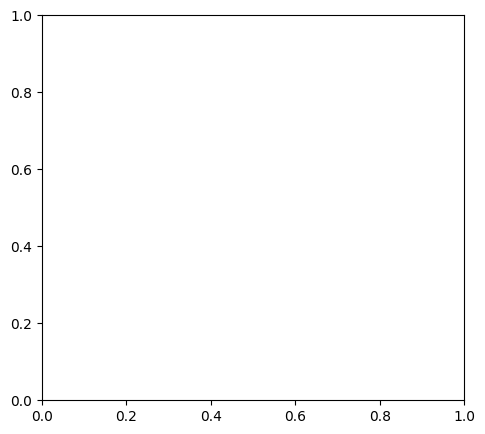

In [11]:
# ============================================================
# CELL 12 — Save Trained Model
# ============================================================

model.save(os.path.join(PROJECT_ROOT, "models", "emotion_hybrid_model.keras"))
print("Model saved successfully.")